## Import +load data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

base_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
master_df = pd.read_csv(os.path.join(base_dir, 'data', 'processed', 'master_df.csv'), index_col=0)

print("✅ Libraries loaded")
print(f"✅ master_df loaded — {master_df.shape}")
print(f"\nColumns available:\n{list(master_df.columns)}")

✅ Libraries loaded
✅ master_df loaded — (3, 19)

Columns available:
['category', 'tam_bn', 'market_cagr_pct', 'pe_deals_2024', 'pe_capital_bn', 'ebitda_margin_pct', 'same_store_growth_pct', 'avg_member_ltv', 'avg_cac', 'ltv_cac_ratio', 'annual_churn_pct', 'hybrid_demand_score', 'macro_resilience', 'us_locations_2025', 'yoy_unit_growth_pct', 'revenue_m', 'gross_margin_pct', 'operating_margin_pct', 'net_income_m']


## Build correlation Dataset

In [2]:
# Combine all numeric signals into one dataframe for correlation analysis
corr_data = pd.DataFrame({
    # Market signals
    'SP500_Return':       [0.313, 0.165, 0.269, -0.195, 0.244, 0.232],   # annual S&P 500
    'Unemployment_Rate':  [3.7,   8.1,   5.4,   3.6,   3.5,   3.7],      # US annual avg %
    'Consumer_Sentiment': [96,    72,    84,     59,    71,    79],        # UMich index
    'Inflation_CPI':      [2.3,   1.2,   4.7,   8.0,   4.1,   3.1],      # US CPI YoY %

    # Fitness category revenue index (2019 = 100)
    'HVLP_Revenue':       [100,   58,    82,    96,    107,   118],
    'Boutique_Revenue':   [100,   42,    71,    88,    94,    99],
    'Digital_Revenue':    [100,   198,   210,   175,   152,   140],

    # PE activity proxy (deal count index)
    'PE_Deal_Index':      [100,   45,    88,    110,   125,   135],
}, index=[2019, 2020, 2021, 2022, 2023, 2024])

print("Correlation dataset shape:", corr_data.shape)
print("\nPreview:")
print(corr_data)

Correlation dataset shape: (6, 8)

Preview:
      SP500_Return  Unemployment_Rate  Consumer_Sentiment  Inflation_CPI  \
2019         0.313                3.7                  96            2.3   
2020         0.165                8.1                  72            1.2   
2021         0.269                5.4                  84            4.7   
2022        -0.195                3.6                  59            8.0   
2023         0.244                3.5                  71            4.1   
2024         0.232                3.7                  79            3.1   

      HVLP_Revenue  Boutique_Revenue  Digital_Revenue  PE_Deal_Index  
2019           100               100              100            100  
2020            58                42              198             45  
2021            82                71              210             88  
2022            96                88              175            110  
2023           107                94              152            125

## Correlation Heatmap

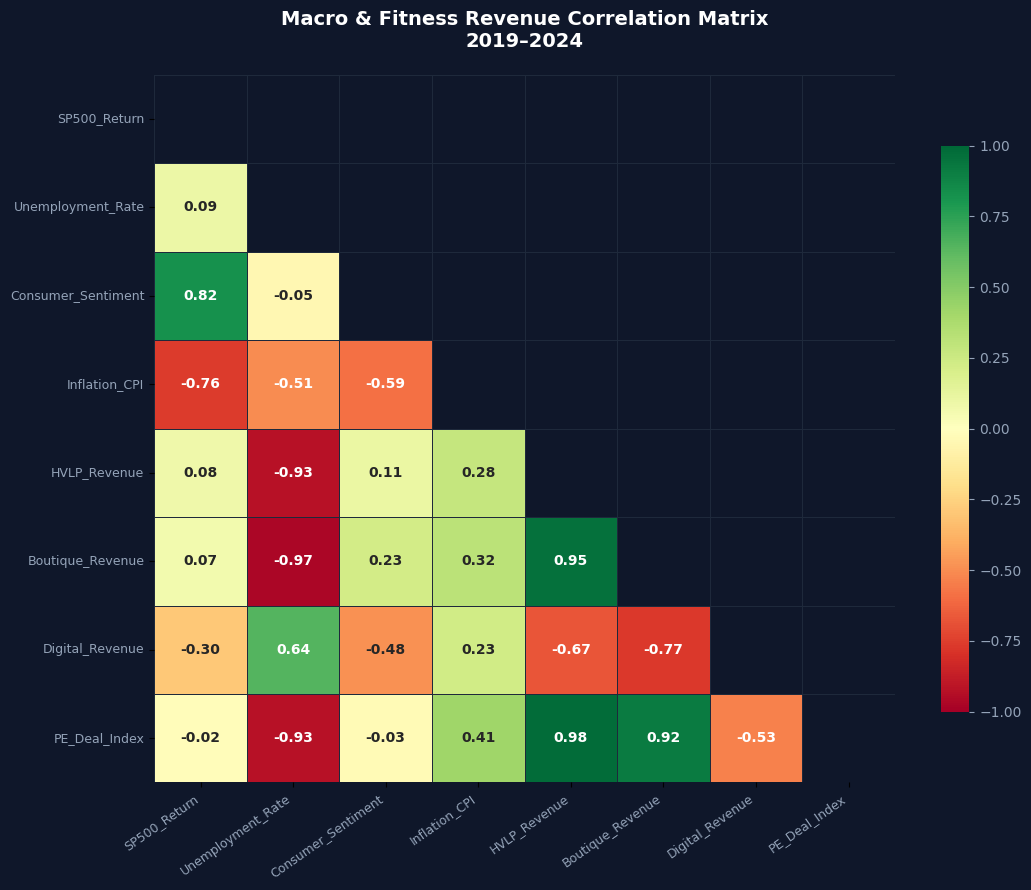

✅ Correlation heatmap saved → output/correlation_heatmap.png


In [3]:
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(11, 9))
fig.patch.set_facecolor('#0f172a')
ax.set_facecolor('#0f172a')

mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True  # show lower triangle only

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=-1, vmax=1,
    center=0,
    linewidths=0.5,
    linecolor='#1e293b',
    ax=ax,
    annot_kws={'size': 10, 'weight': 'bold'},
    cbar_kws={'shrink': 0.8}
)

ax.set_xticklabels(ax.get_xticklabels(), color='#94a3b8', fontsize=9, rotation=35, ha='right')
ax.set_yticklabels(ax.get_yticklabels(), color='#94a3b8', fontsize=9, rotation=0)
ax.set_title('Macro & Fitness Revenue Correlation Matrix\n2019–2024',
             color='white', fontsize=14, fontweight='bold', pad=20)

# Style colorbar
cbar = ax.collections[0].colorbar
cbar.ax.tick_params(colors='#94a3b8')
cbar.ax.yaxis.label.set_color('#94a3b8')

plt.tight_layout()
plt.savefig(os.path.join(base_dir, 'output', 'correlation_heatmap.png'),
            dpi=150, bbox_inches='tight', facecolor='#0f172a')
plt.show()
print("✅ Correlation heatmap saved → output/correlation_heatmap.png")

## Key insights Table

In [4]:
# Extract strongest correlations with each revenue category
insight_rows = []
revenue_cols = ['HVLP_Revenue', 'Boutique_Revenue', 'Digital_Revenue']
macro_cols   = ['SP500_Return', 'Unemployment_Rate', 'Consumer_Sentiment', 'Inflation_CPI', 'PE_Deal_Index']

for rev_col in revenue_cols:
    for mac_col in macro_cols:
        r = corr_matrix.loc[rev_col, mac_col]
        insight_rows.append({
            'Category': rev_col.replace('_Revenue', ''),
            'Macro Factor': mac_col.replace('_', ' '),
            'Correlation (r)': round(r, 2),
            'Strength': 'Strong' if abs(r) >= 0.7 else ('Moderate' if abs(r) >= 0.4 else 'Weak'),
            'Direction': '↑ Positive' if r > 0 else '↓ Negative'
        })

insight_df = pd.DataFrame(insight_rows)
insight_df = insight_df.reindex(insight_df['Correlation (r)'].abs().sort_values(ascending=False).index)

print("TOP CORRELATIONS WITH FITNESS REVENUE:")
print("=" * 65)
print(insight_df[insight_df['Strength'] != 'Weak'].to_string(index=False))

TOP CORRELATIONS WITH FITNESS REVENUE:
Category       Macro Factor  Correlation (r) Strength  Direction
    HVLP      PE Deal Index             0.98   Strong ↑ Positive
Boutique  Unemployment Rate            -0.97   Strong ↓ Negative
    HVLP  Unemployment Rate            -0.93   Strong ↓ Negative
Boutique      PE Deal Index             0.92   Strong ↑ Positive
 Digital  Unemployment Rate             0.64 Moderate ↑ Positive
 Digital      PE Deal Index            -0.53 Moderate ↓ Negative
 Digital Consumer Sentiment            -0.48 Moderate ↓ Negative
